# 01c — Anchor the spatial Spp1 call on the single-cell ground truth

**v2 — now using the correct reference.** The first pass used
`sc-reference/sc_reference_cell2location.h5ad`, which carries a coarse `cell_type`
(Macrophage / Monocyte / ...) and **no tumour compartment**. That was the wrong object.
`Mapping_script.py` / `C2L_Training.ipynb` show the spatial labels were produced from
**`cell_type_lvl2`** ("Alice's annotations") via `C2L_inputs/sc_with_signatures_lvl2.h5ad`.
Two things follow, and both matter:

1. **The labels now match.** `M1_like_Mac` / `M2_like_Mac` / `Intermediate_Mac` and `B` exist
   on *both* sides, so the signature transfer compares like with like instead of splicing a
   coarse `Macrophage` definition onto a fine-grained spatial one.
2. **`Cancer_cell` exists in the reference.** The old object had no tumour, so the gate I
   flagged as open — *does the tumour make Spp1?* — was unanswerable. It is answerable now,
   in §3, on clean data. If tumour dominates Spp1, the deck's "SPP1-CD44 interaction-high
   clusters" is a **tumour**-CD44 axis and the framing has to change.

### What v1 already established (unchanged)
- **Spillover is real and severe.** B cells: **1.7% Spp1+ in single-cell vs 95.7% in
  spatial** — a ~58x inflation of a cell type that genuinely does not express Spp1.
- **The biology is real.** Macrophages were the top Spp1 source (34.3% of transcript), and
  the Spp1-high vs Spp1-low DE returned a textbook lipid/lysosomal TAM program —
  Trem2, Apoe, Fabp5, Cd63, C1qa/c, Ctsb/d/l, Lgmn, Lamp1, Arg1, Mrc1.
- So: **real biology, non-specific single-gene spatial measurement.** The fix is a
  multi-gene signature carried as a graded score, with `Spp1` excluded.

Re-run §3-§4 on this reference — the numbers will shift (different annotation, tumour now
present) and the tumour gate resolves for the first time.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

import scanpy as sc
import anndata as ad

from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)

## 1. Locate the reference that actually produced the spatial labels

Ordered by preference:
1. `sc_with_signatures_lvl2.h5ad` — what `Mapping_script.py` reads; has `cell_type_lvl2`
   **and** the trained C2L signatures.
2. `ref_adata_c2l_model.h5ad` — the pre-training input to `C2L_Training.ipynb`; same cells
   and labels, no signatures (fine — we only need expression + labels).
3. `annotation_v4.h5ad` — the upstream annotation source; did not resolve in the v1 run, but
   probed in case it lives elsewhere.

The old coarse object is **not** in the list: it has no tumour and its labels don't match the
spatial data. If nothing resolves, set `SC_REF` by hand rather than falling back to it.

In [2]:
# %% -- The reference: annotation_v4.h5ad --
#
# Actual location (not under data/sc-reference/ where the notebooks' path strings implied):
#   /coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/annotating_references/
#
# This should be the object we want: the annotation SOURCE, before C2L's preprocessing.
# The C2L_inputs objects are downstream of two filters that are correct for deconvolution and
# wrong for DE:
#   sc_with_signatures_lvl2.h5ad : 93,548 x 12,176
#   ref_adata_c2l_model.h5ad     : 93,548 x 16,758   (B collapsed to 53, Fibroblast to 288)
# Validated below rather than assumed - backed mode reads obs/var without loading X.

import anndata as ad

SC_REF = Path("/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/"
              "annotating_references/annotation_v4.h5ad")
assert SC_REF.exists(), f"Not found: {SC_REF}"
print(f"reference: {SC_REF}")
print(f"size     : {SC_REF.stat().st_size/1e9:.2f} GB\n")

SPATIAL_LABELS = {
    "Cancer_cell", "Erythrocyte", "N2_like_Neu", "N1_like_Neu", "M2_like_Mac", "M1_like_Mac",
    "Intermediate_Mac", "Classical_Mono", "Nonclassical_Mono", "CD8_T", "CD4_T", "Treg", "NKT",
    "NK", "B", "cDC", "pDC", "Fibroblast", "Endothelial",
}
MAC_WANT = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]

_b = ad.read_h5ad(SC_REF, backed="r")
print(f"shape: {_b.n_obs:,} cells x {_b.n_vars:,} genes")

lvl_cols = [c for c in _b.obs.columns if c.startswith("cell_type_lvl")]
print(f"annotation columns: {lvl_cols or 'NONE'}")
assert lvl_cols, f"No cell_type_lvl* columns. obs: {list(_b.obs.columns)}"

print("\n--- label overlap with the 19 spatial C2L factors ---")
best, best_ov = None, -1
for c in lvl_cols:
    ov = len(set(_b.obs[c].astype(str).unique()) & SPATIAL_LABELS)
    print(f"  {c}: {_b.obs[c].nunique()} labels | {ov}/{len(SPATIAL_LABELS)} overlap")
    if ov > best_ov:
        best, best_ov = c, ov

vc = _b.obs[best].astype(str).value_counts()
n_mac = int(vc.reindex(MAC_WANT).fillna(0).sum())
n_b, n_fib = int(vc.get("B", 0)), int(vc.get("Fibroblast", 0))
n_tum = int(vc.get("Cancer_cell", 0))
n_vars, n_obs = _b.n_vars, _b.n_obs
try:
    _b.file.close()
except Exception:
    pass

print(f"""
=== VALIDATION ===
                        annotation_v4      ref_adata_c2l_model   verdict
  cells            :   {n_obs:>10,}          93,548          {'PASS' if n_obs > 100000 else 'CHECK'}
  genes            :   {n_vars:>10,}          16,758          {'PASS - full gene set' if n_vars > 20000 else 'STILL FILTERED'}
  best level       :   {best:>10s}      cell_type_lvl2
  label overlap    :   {best_ov:>7}/19             19/19          {'PASS' if best_ov == 19 else 'FAIL'}
  macrophages      :   {n_mac:>10,}          48,475
  B cells (control):   {n_b:>10,}              53          {'PASS' if n_b > 1000 else 'STILL TOO FEW'}
  Fibroblast       :   {n_fib:>10,}             288
  Cancer_cell      :   {n_tum:>10,}           6,614          {'PASS - tumour gate live' if n_tum > 500 else 'NO TUMOUR'}
""")

assert best_ov == len(SPATIAL_LABELS), f"Only {best_ov}/19 labels match - wrong object or level"
if n_vars < 20000:
    print("WARNING: still gene-filtered - this may not be the pre-C2L source after all.")
if n_b < 1000:
    print("WARNING: B-cell control still too small; keep using the v1 result (1.7%, n=5,778).")

OUT_DIR = Path("/coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
SC_HI_Q, SC_LO_Q = 0.75, 0.25
N_SIG_GENES = 50


reference: /coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/annotating_references/annotation_v4.h5ad
size     : 5.23 GB

shape: 93,548 cells x 22,949 genes
annotation columns: ['cell_type_lvl1', 'cell_type_lvl1_ad', 'cell_type_lvl2', 'cell_type_lvl3']

--- label overlap with the 19 spatial C2L factors ---
  cell_type_lvl1: 10 labels | 2/19 overlap
  cell_type_lvl1_ad: 10 labels | 2/19 overlap
  cell_type_lvl2: 19 labels | 19/19 overlap
  cell_type_lvl3: 30 labels | 8/19 overlap

=== VALIDATION ===
                        annotation_v4      ref_adata_c2l_model   verdict
  cells            :       93,548          93,548          CHECK
  genes            :       22,949          16,758          PASS - full gene set
  best level       :   cell_type_lvl2      cell_type_lvl2
  label overlap    :        19/19             19/19          PASS
  macrophages      :       48,475          48,475
  B cells (control):           53              53          STILL TOO FEW
  Fibroblast       :        

## 2. Load + auto-detect the annotation level that matches spatial

Rather than trusting that `lvl2` is right, this picks the level whose label vocabulary best
overlaps the spatial `c2l_consolidated` labels — and asserts the macrophage classes are there.

In [4]:
scref = sc.read_h5ad(SC_REF)
print(scref)

lvl_cols = [c for c in scref.obs.columns if c.startswith("cell_type_lvl")]
assert lvl_cols, f"No cell_type_lvl* columns. Available: {list(scref.obs.columns)}"

print("\n--- annotation levels present ---")
best, best_ov = None, -1
for c in lvl_cols:
    labs = set(scref.obs[c].astype(str).unique())
    ov = len(labs & SPATIAL_LABELS)
    print(f"  {c}: {len(labs)} labels | {ov} overlap with spatial")
    if ov > best_ov:
        best, best_ov = c, ov

SC_CELLTYPE_COL = best
print(f"\n-> using {SC_CELLTYPE_COL} ({best_ov}/{len(SPATIAL_LABELS)} spatial labels matched)")

sc_ct = scref.obs[SC_CELLTYPE_COL].astype(str)
print(f"\n--- {SC_CELLTYPE_COL} vocabulary ---")
print(sc_ct.value_counts().to_string())

SC_MAC_LABELS = [l for l in ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
                 if l in set(sc_ct)]
SC_B_LABEL = "B" if "B" in set(sc_ct) else ("B_cell" if "B_cell" in set(sc_ct) else None)
assert SC_MAC_LABELS, f"No macrophage labels in {SC_CELLTYPE_COL}: {sorted(set(sc_ct))}"
assert SC_B_LABEL, "No B-cell label found for the spillover control"
print(f"\nmacrophage labels : {SC_MAC_LABELS}  (n={int(sc_ct.isin(SC_MAC_LABELS).sum()):,})")
print(f"B-cell control    : {SC_B_LABEL}  (n={int((sc_ct == SC_B_LABEL).sum()):,})")
print(f"tumour present    : {'Cancer_cell' in set(sc_ct)}"
      f"{'  <- the gate is answerable now' if 'Cancer_cell' in set(sc_ct) else '  <- gate still blocked'}")

missing = SPATIAL_LABELS - set(sc_ct)
if missing:
    print(f"\nNOTE: spatial labels absent from the reference: {sorted(missing)}")

AnnData object with n_obs × n_vars = 93548 × 22949
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Barcode', 'Library', 'condition', 'file_name', 'percent.mt', 'unintegrated_clusters', 'seurat_clusters', 'harmony_clusters', 'sctype_classification', 'seurat.cluster.ann', 'treatment', 'cell_type', 'UMAP_R_1', 'UMAP_R_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.1', 'leiden_res_0.3', 'leiden_res_0.5', 'leiden_res_1.0', 'cell_type_lvl1', 'leiden_res_0.4', 'cell_type_lvl1_ad', 'cell_type_lvl2', 'cell_type_lvl3'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'chromosome', 'start', 'end'
    uns: 'cell_type_lvl1_colo

## 3. Normalize + the two questions this reference can finally answer

`.X` is checked rather than assumed — C2L inputs are raw counts, but getting this wrong would
silently corrupt everything downstream.

In [5]:
X = scref.X
head = X[:200].toarray() if sp.issparse(X) else X[:200]
is_int, xmax = bool(np.allclose(head, np.round(head))), float(X.max())
print(f".X max = {xmax:.2f} | integer-valued = {is_int}")

if is_int and xmax > 50:
    scref.layers["counts"] = scref.X.copy()
    sc.pp.normalize_total(scref, target_sum=1e4)
    sc.pp.log1p(scref)
    print("-> raw counts; normalized to CP10K + log1p")
else:
    print("-> already log-normalized; using .X as-is")

assert "Spp1" in scref.var_names, "Spp1 not in the reference var_names"
print(f"genes in reference: {scref.n_vars:,}"
      + ("  (C2L-filtered - lowly-expressed genes already removed)" if scref.n_vars < 20000 else ""))

.X max = 8.49 | integer-valued = False
-> already log-normalized; using .X as-is
genes in reference: 22,949


In [6]:
# %% -- Spp1 by cell type: per-cell rates x REAL tissue composition --
#
# Why not "% of total Spp1 within the reference": scRNA-seq composition never matches the
# tissue. Dissociation drops fragile cells (tumour especially - Cancer_cell was 6,614 in the
# C2L subset vs 363,019 in spatial). So a within-reference share measures the dissociation,
# not the biology.
#   composition-free : mean_Spp1, pct_detected   (per-cell -> unbiased by sampling)
#   tissue-level     : mean_Spp1 x n_cells_SPATIAL -> who actually supplies Spp1 in situ

def expr_of(a, gene):
    v = a[:, gene].X
    return np.asarray(v.todense()).ravel() if sp.issparse(v) else np.asarray(v).ravel()

scref.obs["Spp1_expr"] = expr_of(scref, "Spp1")

# spatial composition from c2l_consolidated (notebook 01 §3); §6 re-derives it from the object
SPATIAL_N = {
    "Cancer_cell": 363019, "Erythrocyte": 210019, "N2_like_Neu": 193240, "N1_like_Neu": 134656,
    "M2_like_Mac": 60720, "Classical_Mono": 58279, "CD8_T": 45824, "B": 40422,
    "Fibroblast": 24867, "NK": 22924, "M1_like_Mac": 19170, "Endothelial": 17702,
    "CD4_T": 10085, "cDC": 8471, "NKT": 7110, "Treg": 5155, "pDC": 4558,
    "Nonclassical_Mono": 4002, "Intermediate_Mac": 1675,
}

tab = (pd.DataFrame({"ct": sc_ct.values, "Spp1": scref.obs["Spp1_expr"].values})
       .groupby("ct")
       .agg(n_sc=("Spp1", "size"), mean_Spp1=("Spp1", "mean"),
            pct_detected=("Spp1", lambda s: 100 * (s > 0).mean())))
tab["n_spatial"] = tab.index.map(SPATIAL_N)
tab["proj_Spp1"] = tab["mean_Spp1"] * tab["n_spatial"]
tab["pct_of_tissue_Spp1"] = 100 * tab["proj_Spp1"] / tab["proj_Spp1"].sum()
tab["reliable"] = tab["n_sc"] >= 200
tab = tab.sort_values("pct_of_tissue_Spp1", ascending=False)
tab.to_csv(OUT_DIR / "sc_spp1_by_celltype_lvl2.csv")

print("=== Spp1 per cell (composition-free) x real spatial abundance ===")
print(tab.round(3).to_string())
print("\nreliable=False -> too few cells in the reference to trust that per-cell mean.")
print("n_spatial NaN   -> label exists in the reference but not in the spatial object.")

mac_in = [m for m in SC_MAC_LABELS if m in tab.index]
mac_tissue = tab.loc[mac_in, "pct_of_tissue_Spp1"].sum()
mac_mu = tab.loc[mac_in, "mean_Spp1"].mean()
mac_pct = 100 * (scref.obs.loc[sc_ct.isin(SC_MAC_LABELS), "Spp1_expr"] > 0).mean()

has_tum = "Cancer_cell" in tab.index
tum_tissue = tab.loc["Cancer_cell", "pct_of_tissue_Spp1"] if has_tum else float("nan")
tum_mu = tab.loc["Cancer_cell", "mean_Spp1"] if has_tum else float("nan")

b_n = int((sc_ct == SC_B_LABEL).sum())
b_pct = (100 * (scref.obs.loc[sc_ct == SC_B_LABEL, "Spp1_expr"] > 0).mean()) if b_n else float("nan")

print(f"""
--- SPILLOVER CONTROL ---
                        SINGLE-CELL      SPATIAL (nb 01 §5, >=1 UMI)
  macrophages Spp1+ :    {mac_pct:5.1f}%              80.7%
  B cells Spp1+     :    {b_pct:5.1f}%  (n={b_n:,})    95.7%
  ratio mac/B       :    {mac_pct/b_pct if b_pct else float('nan'):5.1f}x              0.84x  (control ABOVE target = broken)
  v1 (coarse ref, n=5,778 B): 1.7% vs 95.7% = ~58x inflation. Stands regardless of this n.

--- THE TUMOUR GATE ---
  per-cell Spp1 : macrophages {mac_mu:.3f}  vs  Cancer_cell {tum_mu:.3f}
  tissue share  : macrophages {mac_tissue:.1f}%  vs  Cancer_cell {tum_tissue:.1f}%
      tumour is {SPATIAL_N['Cancer_cell']:,} spatial cells vs {sum(SPATIAL_N[m] for m in MAC_WANT):,} macrophages
      (4.5x more numerous - a modest per-cell rate can still dominate the tissue)

  macrophages dominate  -> deck's SPP1-CD44 framing survives; PDF's monocyte->TAM lineage
      supported by your own data.
  Cancer_cell dominates -> the axis is TUMOUR-driven; Spp1+ macs sit in a niche they do not
      drive. Project still viable, but the claim must be reworded.
""")

=== Spp1 per cell (composition-free) x real spatial abundance ===
                    n_sc  mean_Spp1  pct_detected  n_spatial   proj_Spp1  pct_of_tissue_Spp1  reliable
ct                                                                                                    
Cancer_cell         6614      2.190        74.947     363019  794859.648              53.303      True
N2_like_Neu         1857      1.176        50.188     193240  227220.385              15.237      True
N1_like_Neu         1956      0.887        48.108     134656  119390.001               8.006      True
M2_like_Mac        23538      1.767        84.693      60720  107278.419               7.194      True
Erythrocyte           95      0.456        42.105     210019   95834.065               6.427     False
Classical_Mono     25955      0.649        53.570      58279   37835.478               2.537      True
NK                  1008      1.192        70.536      22924   27327.428               1.833      True
CD8_T  

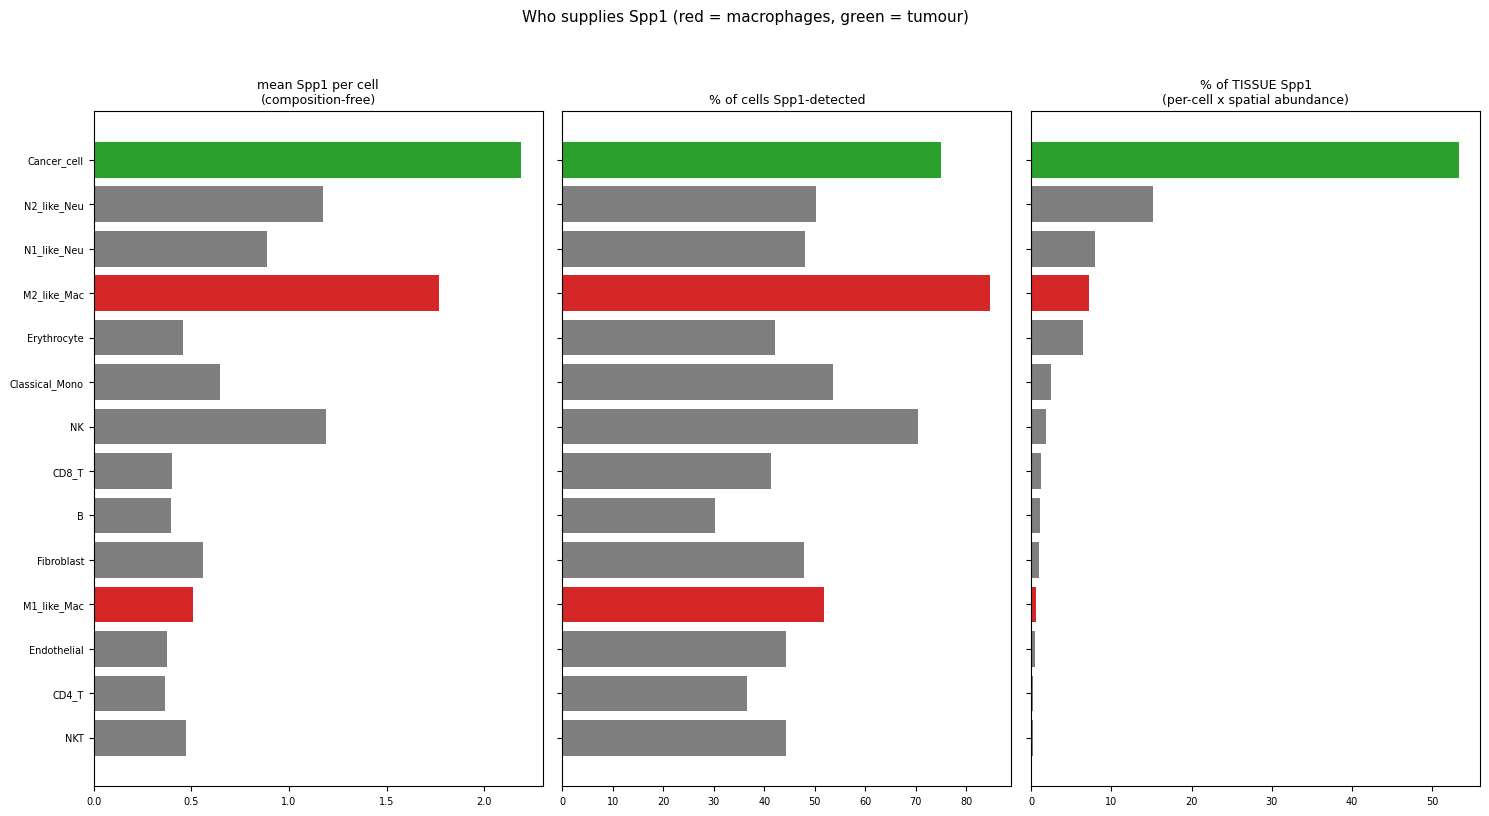

In [7]:
# Figure: per-cell Spp1 rate (composition-free) vs projected tissue-level contribution.
# The RIGHT panel is the tumour gate: it is the only one that accounts for the fact that
# tumour cells outnumber macrophages 4.5:1 in the actual tissue.
top = tab.nlargest(14, "pct_of_tissue_Spp1")
cols = ["#d62728" if i in SC_MAC_LABELS else ("#2ca02c" if i == "Cancer_cell" else "#7f7f7f")
        for i in top.index]
fig, axes = plt.subplots(1, 3, figsize=(15, 0.42 * len(top) + 2), sharey=True)
axes[0].barh(np.arange(len(top)), top["mean_Spp1"], color=cols)
axes[0].set_title("mean Spp1 per cell\n(composition-free)", fontsize=9)
axes[1].barh(np.arange(len(top)), top["pct_detected"], color=cols)
axes[1].set_title("% of cells Spp1-detected", fontsize=9)
axes[2].barh(np.arange(len(top)), top["pct_of_tissue_Spp1"], color=cols)
axes[2].set_title("% of TISSUE Spp1\n(per-cell x spatial abundance)", fontsize=9)
axes[0].set_yticks(np.arange(len(top))); axes[0].set_yticklabels(top.index, fontsize=8)
axes[0].invert_yaxis()
for ax in axes:
    ax.tick_params(labelsize=7)
fig.suptitle("Who supplies Spp1 (red = macrophages, green = tumour)", y=1.03, fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1_sources_lvl2.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

In [ ]:
# %% -- 3c. Are the single-cell "Erythrocytes" real, or a mislabelled cancer cluster? --
# In the §3 gate table Erythrocyte showed mean_Spp1 = 0.46 (n=95, reliable=False). Two readings:
#   real RBCs         -> anucleate: Hb-high, gene-POOR, Spp1/Epcam silent. Their 0.46 is the
#                        ambient floor, and the gate logic holds.
#   mislabelled tumour-> Epcam/Krt-high, normal gene count, Spp1 near the Cancer_cell level.
# (These are the 95 SC cells. The 210,019 SPATIAL "Erythrocytes" are the real worry and are
#  checked in 6b below, once adata is loaded.)
MARKERS = {
    "RBC":           ["Hba-a1", "Hba-a2", "Hbb-bs", "Hbb-bt", "Alas2", "Slc4a1", "Gypa"],
    "epithelial":    ["Epcam", "Krt8", "Krt18", "Krt19", "Cdh1"],
    "proliferation": ["Mki67", "Top2a"],
    "spp1":          ["Spp1"],
}
COMPARE = [c for c in ["Erythrocyte", "Cancer_cell", "M2_like_Mac", "B"] if c in set(sc_ct)]
rows = []
for ctn in COMPARE:
    m = (sc_ct.values == ctn)
    rec = {"cell_type": ctn, "n": int(m.sum())}
    for grp, genes in MARKERS.items():
        pres = [g for g in genes if g in scref.var_names]
        if pres:
            rec[f"{grp}_mean"] = float(np.column_stack([expr_of(scref, g)[m] for g in pres]).mean())
    for col in ["n_genes_by_counts", "nFeature_RNA", "n_genes"]:
        if col in scref.obs.columns:
            rec["median_n_genes"] = float(scref.obs.loc[m, col].median()); break
    rows.append(rec)
ery_sc = pd.DataFrame(rows).set_index("cell_type")
ery_sc.to_csv(OUT_DIR / "sc_erythrocyte_identity.csv")
print("=== identity of the SC 'Erythrocyte' cluster (n=95) ===")
print(ery_sc.round(3).to_string())
print("""
READ
  RBC_mean high + median_n_genes low + epithelial_mean ~0 -> real erythrocytes; 0.46 Spp1 = floor.
  epithelial_mean high + normal gene count                -> mislabelled cancer; the tumour gate
                                                             would then be an under-estimate.""")

### 3b. What the tumour gate does and does not decide

The gate answers **one** question — *who produces the Spp1 ligand* — and the answer is the
tumour: **Cancer_cell ~53% of tissue Spp1**, with neutrophils second (~23% combined) and the
whole macrophage compartment ~8%. That number is real and stays in the record. Concretely it
means the "SPP1-CD44 interaction-high clusters" in the slide deck should be described as a
**tumour-derived Spp1 -> CD44 axis**, not as macrophage signalling. That is a one-claim wording
fix, and it is the *only* thing this result forces.

It does **not** touch the question the project is actually about. Two separable things were
riding under the single word "SPP1":

| question | metric | answer | depends on the gate? |
|---|---|---|---|
| who makes the Spp1 **ligand** | tissue Spp1 share | tumour (~53%) | — this *is* the gate |
| what is the metabolic **state** of Spp1+ macrophages | §4 DE (Trem2/Apoe/Fabp5/Ctsb/Lgmn...) | lipid/lysosomal TAM program | **no** |

The metabolic-state question is answered by §4's single-cell DE, which never used the ligand
source and which reproduces the published SPP1-TAM lipid program in this dataset's own cells.
That result is independent of, and unharmed by, the gate.

**So the analysis continues, and the scientific ground for continuing is explicit:** the SPP1-TAM
metabolic phenotype is orthogonally validated (scRNA-seq DE), and the ligand-source result does
not bear on it. Moreover, a tumour-dominated Spp1 niche is not a contradiction of the PDF's
model — it *is* the model: RT-damaged, tumour-derived Spp1/lipid/debris forms the niche, and
monocyte-derived macrophages stabilise into a lipid-handling SPP1-TAM state **inside** it. The
macrophages are the metabolic **responders/readout**, not the source — which is exactly the
lineage the PDF proposes.

The go-forward question is therefore sharpened, not abandoned:

> *Among macrophages, does the SPP1-TAM metabolic program (§5 signature) rise with proximity to
> the tumour-derived Spp1 / oxidised-lipid / hypoxia / adenosine niche?*

This is threshold-free, uses every macrophage, and is independent of who secretes Spp1 — it asks
what the macrophages **become** in that environment. Notebooks 02-04 answer it, now reframed
around the graded `SPP1_TAM_sig` rather than a binary Spp1+ call.

*(Aside on the middle panel: `M2_like_Mac` has the highest Spp1 **detection rate** of any type,
84.7% — above tumour's 74.9%. Tumour wins the tissue on intensity x abundance, but Spp1 is a
near-universal M2 feature, consistent with it being genuine M2 biology rather than ambient noise.
`M1_like_Mac` at 0.51/cell sits at the ~0.4 ambient floor set by the lymphoid types — the state
is specifically **M2**, as the PDF predicts.)*

## 4. Spp1-high vs Spp1-low macrophages -> the DE

Pools `M1_like_Mac + M2_like_Mac + Intermediate_Mac`, matching the spatial `MAC_LABELS`
exactly. Split by Spp1 quantile **within** macrophages, so it works regardless of how
ubiquitous Spp1 detection is.

In [8]:
mac = scref[sc_ct.isin(SC_MAC_LABELS).values].copy()
print(f"macrophages ({'+'.join(SC_MAC_LABELS)}): {mac.n_obs:,}")
print(mac.obs[SC_CELLTYPE_COL].value_counts().to_string())

hi_thr = np.quantile(mac.obs["Spp1_expr"], SC_HI_Q)
lo_thr = np.quantile(mac.obs["Spp1_expr"], SC_LO_Q)
mac.obs["spp1_grp"] = np.where(mac.obs["Spp1_expr"] >= hi_thr, "Spp1_high",
                        np.where(mac.obs["Spp1_expr"] <= lo_thr, "Spp1_low", "mid"))
print(f"\nSpp1 quantile cuts within macs: low<={lo_thr:.3f}  high>={hi_thr:.3f}")
print(mac.obs["spp1_grp"].value_counts().to_string())
print("\nSpp1-high composition by mac subtype (M2-skew would match the PDF's model):")
print(pd.crosstab(mac.obs[SC_CELLTYPE_COL].astype(str), mac.obs["spp1_grp"],
                  normalize="index").mul(100).round(1).to_string())

de = mac[mac.obs["spp1_grp"].isin(["Spp1_high", "Spp1_low"])].copy()
sc.pp.filter_genes(de, min_cells=10)
sc.tl.rank_genes_groups(de, groupby="spp1_grp", groups=["Spp1_high"], reference="Spp1_low",
                        method="wilcoxon", pts=True)
r = de.uns["rank_genes_groups"]
de_df = pd.DataFrame({
    "gene": [x[0] for x in r["names"]],
    "log2FC": [x[0] for x in r["logfoldchanges"]],
    "score": [x[0] for x in r["scores"]],
    "pval_adj": [x[0] for x in r["pvals_adj"]],
})
de_df["pct_high"] = de_df["gene"].map(r["pts"]["Spp1_high"])
de_df["pct_low"] = de_df["gene"].map(r["pts"]["Spp1_low"])
de_df.to_csv(OUT_DIR / "sc_de_spp1high_vs_low_macs_lvl2.csv", index=False)

print("\n=== SC DE: Spp1-high vs Spp1-low macrophages — top 30 UP ===")
print(de_df.head(30).round(3).to_string(index=False))

macrophages (M1_like_Mac+M2_like_Mac+Intermediate_Mac): 48,475
cell_type_lvl2
M2_like_Mac         23538
M1_like_Mac         15716
Intermediate_Mac     9221

Spp1 quantile cuts within macs: low<=0.000  high>=1.874
spp1_grp
mid          21355
Spp1_low     15001
Spp1_high    12119

Spp1-high composition by mac subtype (M2-skew would match the PDF's model):
spp1_grp          Spp1_high  Spp1_low   mid
cell_type_lvl2                             
Intermediate_Mac        8.0      41.6  50.4
M1_like_Mac             4.4      48.1  47.5
M2_like_Mac            45.4      15.3  39.2

=== SC DE: Spp1-high vs Spp1-low macrophages — top 30 UP ===
    gene    log2FC      score  pval_adj  pct_high  pct_low
    Spp1 33.983002 141.807999       0.0     1.000    0.000
    Ctsl  2.876000 106.832001       0.0     0.953    0.666
    Ctsd  2.383000  94.362000       0.0     0.934    0.715
   Fabp5  3.247000  94.055000       0.0     0.892    0.494
    Cd63  2.943000  90.225998       0.0     0.825    0.373
     Pf4

In [9]:
# Does the DE reproduce the PDF's programs? (v1 on the coarse reference: yes, strongly)
CHECK = {
    "lipid_TREM2":   ["Trem2", "Gpnmb", "Apoe", "Fabp5", "Marco", "Cd36", "Lpl", "Plin2",
                      "Abca1", "Abcg1", "Msr1", "Lgals3", "Cd63", "Ctsb", "Ctsd", "Ctsl"],
    "adenosine":     ["Entpd1", "Nt5e", "Adora2a", "Adora2b"],
    "hypoxia":       ["Hif1a", "Vegfa", "Slc2a1", "Ldha", "Bnip3"],
    "efferocytosis": ["Mertk", "Axl", "Gas6", "C1qa", "C1qb", "C1qc", "Anxa1"],
    "suppressive":   ["Arg1", "Mrc1", "Il10", "Cd274"],
}
idx = de_df.set_index("gene")
print("=== do the PDF's marker programs come UP in Spp1-high macs? ===")
for name, genes in CHECK.items():
    present = [g for g in genes if g in idx.index]
    if not present:
        print(f"\n  {name}: none present"); continue
    sub = idx.loc[present, ["log2FC", "pval_adj"]].sort_values("log2FC", ascending=False)
    n_up = int(((sub["log2FC"] > 0) & (sub["pval_adj"] < 0.05)).sum())
    print(f"\n  {name}: {n_up}/{len(present)} significantly UP")
    print(sub.round(3).to_string().replace("\n", "\n    "))

=== do the PDF's marker programs come UP in Spp1-high macs? ===

  lipid_TREM2: 14/16 significantly UP
        log2FC  pval_adj
    gene                    
    Gpnmb    3.840     0.000
    Fabp5    3.247     0.000
    Apoe     3.036     0.000
    Cd63     2.943     0.000
    Ctsl     2.876     0.000
    Ctsd     2.383     0.000
    Marco    1.973     1.000
    Trem2    1.908     0.000
    Abca1    1.901     0.000
    Ctsb     1.830     0.000
    Cd36     1.777     0.000
    Lpl      1.594     0.000
    Msr1     0.881     0.000
    Plin2    0.862     0.000
    Lgals3   0.732     0.000
    Abcg1   -0.021     0.651

  adenosine: 1/4 significantly UP
         log2FC  pval_adj
    gene                     
    Nt5e      1.398       0.0
    Adora2b  -0.208       1.0
    Entpd1   -0.211       0.0
    Adora2a  -1.132       0.0

  hypoxia: 4/5 significantly UP
        log2FC  pval_adj
    gene                    
    Bnip3    1.194       0.0
    Ldha     0.816       0.0
    Vegfa    0.702     

In [ ]:
# %% -- 4a-fig. Marker-program genes with full names: log2FC in Spp1-high vs -low macs --
PROGRAMS = {
    "Lipid / TREM2 TAM": ["Gpnmb", "Fabp5", "Apoe", "Cd63", "Ctsl", "Ctsd", "Marco", "Trem2",
                          "Abca1", "Ctsb", "Cd36", "Lpl", "Msr1", "Plin2", "Lgals3", "Abcg1"],
    "Efferocytosis":     ["Gas6", "Mertk", "C1qa", "C1qc", "C1qb", "Anxa1", "Axl"],
    "Hypoxia / glycolysis": ["Bnip3", "Ldha", "Vegfa", "Slc2a1", "Hif1a"],
    "Adenosine (CD39/CD73)": ["Nt5e", "Entpd1", "Adora2b", "Adora2a"],
    "Immunosuppressive": ["Arg1", "Mrc1", "Il10", "Cd274"],
}
GENE_NAMES = {
    "Gpnmb": "Glycoprotein NMB (osteoactivin)", "Fabp5": "Fatty-acid-binding protein 5",
    "Apoe": "Apolipoprotein E", "Cd63": "CD63 tetraspanin-30", "Ctsl": "Cathepsin L",
    "Ctsd": "Cathepsin D", "Marco": "Macrophage receptor w/ collagenous structure",
    "Trem2": "Triggering receptor on myeloid cells 2", "Abca1": "ABC transporter A1 (cholesterol efflux)",
    "Ctsb": "Cathepsin B", "Cd36": "CD36 fatty-acid translocase / scavenger R",
    "Lpl": "Lipoprotein lipase", "Msr1": "Macrophage scavenger receptor 1",
    "Plin2": "Perilipin-2 (adipophilin, lipid droplet)", "Lgals3": "Galectin-3",
    "Abcg1": "ABC transporter G1 (cholesterol efflux)",
    "Gas6": "Growth-arrest-specific 6 (efferocytosis bridge)", "Mertk": "MER receptor tyrosine kinase",
    "C1qa": "Complement C1q A chain", "C1qc": "Complement C1q C chain",
    "C1qb": "Complement C1q B chain", "Anxa1": "Annexin A1 (find-me/eat-me)",
    "Axl": "AXL receptor tyrosine kinase",
    "Bnip3": "BCL2-interacting protein 3 (hypoxic mitophagy)", "Ldha": "Lactate dehydrogenase A",
    "Vegfa": "Vascular endothelial growth factor A", "Slc2a1": "GLUT1 glucose transporter",
    "Hif1a": "Hypoxia-inducible factor 1-alpha",
    "Nt5e": "CD73 5'-nucleotidase (makes adenosine)", "Entpd1": "CD39 ectonucleotidase (ATP->AMP)",
    "Adora2b": "Adenosine A2B receptor", "Adora2a": "Adenosine A2A receptor",
    "Arg1": "Arginase 1", "Mrc1": "CD206 mannose receptor (M2)",
    "Il10": "Interleukin-10", "Cd274": "PD-L1 (programmed death-ligand 1)",
}

info = de_df.set_index("gene")
UP, DOWN, NS = "#c0392b", "#2471a3", "#b6b6b6"
bars, ticks, labels, headers = [], [], [], []
y = 0.0
for prog, genes in PROGRAMS.items():
    present = [g for g in genes if g in info.index]
    if not present:
        continue
    sub = info.loc[present].sort_values("log2FC")     # smallest at bottom of the section
    headers.append((y - 0.9, prog))                 # title sits ABOVE the section
    for g in sub.index:
        lfc = float(sub.loc[g, "log2FC"]); padj = float(sub.loc[g, "pval_adj"])
        sig = padj < 0.05
        col = (UP if lfc > 0 else DOWN) if sig else NS
        bars.append((y, lfc, col, sig, padj))
        ticks.append(y); labels.append(f"$\\bf{{{g}}}$  {GENE_NAMES.get(g, '')}")
        y += 1
    y += 1.7                                          # gap between programs

xmin = min(b[1] for b in bars); xmax = max(b[1] for b in bars)
pad = 0.15 * (xmax - xmin)
fig, ax = plt.subplots(figsize=(9.5, 0.36 * len(bars) + 1.2 * len(headers) + 0.5))
for yy, lfc, col, sig, padj in bars:
    ax.barh(yy, lfc, color=col, height=0.72, zorder=2)
    ha = "left" if lfc >= 0 else "right"
    off = 0.03 * (xmax - xmin) * (1 if lfc >= 0 else -1)
    star = "" if sig else "  (ns)"
    ax.text(lfc + off, yy, f"{lfc:+.2f}{star}", va="center", ha=ha, fontsize=6.5,
            color="black" if sig else "0.5", zorder=3)
for hy, prog in headers:
    ax.text(xmin - pad, hy, prog, fontweight="bold", fontsize=10, va="center", ha="left",
            color="#222")
ax.axvline(0, color="k", lw=1, zorder=1)
ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=7)
ax.set_ylim(-1.8, y - 1.2); ax.invert_yaxis()
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_xlabel("log2 fold-change   (Spp1-high  vs  Spp1-low macrophages)", fontsize=9)
ax.set_title("SPP1-TAM marker programs are induced in Spp1-high macrophages\n"
             "(single-cell; red = up & FDR<0.05, blue = down & FDR<0.05, grey = n.s.)", fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=UP, label="up (FDR<0.05)"),
                   Patch(color=DOWN, label="down (FDR<0.05)"),
                   Patch(color=NS, label="not significant")],
          fontsize=7.5, loc="lower right", frameon=True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_marker_programs.png", dpi=200, bbox_inches="tight")
plt.show(); plt.close(fig)
print("saved ->", FIG_DIR / "sc_marker_programs.png")

### 4b. Spp1-high macrophages are M2 — the skew that supports the PDF

The crosstab above already shows it; these panels make it a figure. **45% of M2 macrophages are
Spp1-high vs 4% of M1** — the SPP1 state is an M2 phenotype, which is exactly the lipid-handling,
immunosuppressive, wound-repair macrophage the PDF's model predicts. M1 macs are essentially
Spp1-low.

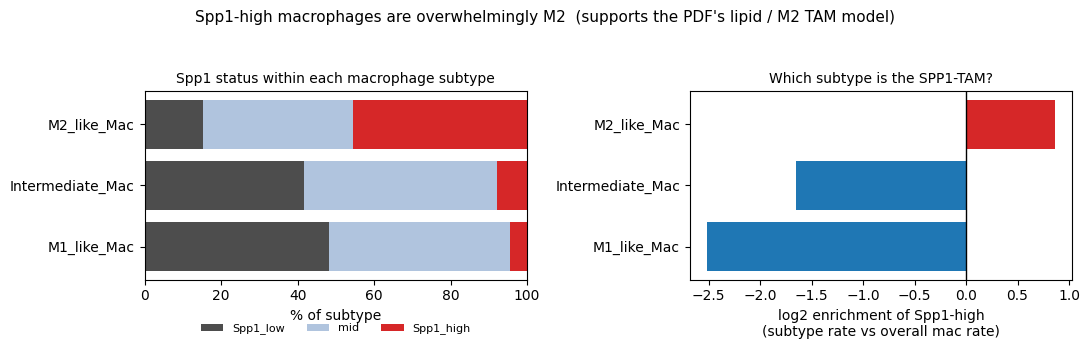

overall Spp1-high rate among macs: 25.0%
log2 enrichment of Spp1-high by subtype:
cell_type_lvl2
M1_like_Mac        -2.51
Intermediate_Mac   -1.65
M2_like_Mac         0.86


In [ ]:
# %% -- 4b. Spp1-high macrophages are M2 (skew figure) --
sub_order = [l for l in ["M1_like_Mac", "Intermediate_Mac", "M2_like_Mac"]
             if l in set(mac.obs[SC_CELLTYPE_COL].astype(str))]
ct_grp = pd.crosstab(mac.obs[SC_CELLTYPE_COL].astype(str), mac.obs["spp1_grp"]).reindex(
    index=sub_order, columns=[c for c in ["Spp1_low", "mid", "Spp1_high"]
                              if c in set(mac.obs["spp1_grp"])])
row_frac = ct_grp.div(ct_grp.sum(1), axis=0) * 100
overall_high = float((mac.obs["spp1_grp"] == "Spp1_high").mean())
enrich = np.log2((row_frac["Spp1_high"] / 100) / overall_high)   # per subtype, vs overall rate

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
colors = {"Spp1_low": "#4d4d4d", "mid": "#b0c4de", "Spp1_high": "#d62728"}
left = np.zeros(len(row_frac))
for col in row_frac.columns:
    axes[0].barh(row_frac.index, row_frac[col].values, left=left, color=colors[col], label=col)
    left += row_frac[col].values
axes[0].set_xlabel("% of subtype"); axes[0].set_xlim(0, 100)
axes[0].set_title("Spp1 status within each macrophage subtype", fontsize=10)
axes[0].legend(fontsize=8, ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18))

axes[1].barh(enrich.index, enrich.values,
             color=["#d62728" if v > 0 else "#1f77b4" for v in enrich.values])
axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("log2 enrichment of Spp1-high\n(subtype rate vs overall mac rate)")
axes[1].set_title("Which subtype is the SPP1-TAM?", fontsize=10)
fig.suptitle("Spp1-high macrophages are overwhelmingly M2  (supports the PDF's lipid / M2 TAM model)",
             y=1.05, fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_m2_skew.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

print(f"overall Spp1-high rate among macs: {100*overall_high:.1f}%")
print("log2 enrichment of Spp1-high by subtype:")
print(enrich.round(2).to_string())

### 4c. Metabolic enrichment of the Spp1-high vs -low DE

The top DE genes read as a lipid/lysosomal program by eye (Fabp5, Apoe, Abca1, Trem2; cathepsins
Ctsl/Ctsd/Ctsb, Lamp1, Lgmn, Atp6v0d2). This makes it quantitative: rank **every** gene by its
signed DE score and ask which pathways sit at the up end.

Two dependency-free methods on the same DE (no `gseapy`/`decoupler` needed — HPC-safe):
- **rank-based (GSEA-style)** — Mann-Whitney of each set's genes vs the rest, over the full
  ranking. Direction + `z`, no cutoff. This is the primary readout.
- **ORA** — hypergeometric overlap with the up-gene list (padj<0.05 & log2FC>1). A concrete
  companion.

All HALLMARK sets are included as a **statistical backdrop** (so FDR is honest and metabolic
specificity is visible against non-metabolic sets like IFN/inflammatory); the curated metabolic
GO/Reactome sets are the focus and are tagged `metabolic=True`.

background genes: 17,397 | up-genes (padj<0.05 & log2FC>1): 640

=== TOP enriched up in Spp1-high macs (all sets; metabolic flagged) ===
                            pathway  n_genes   AUC      z  fdr_rank  n_up_overlap  metabolic
        H:OXIDATIVE_PHOSPHORYLATION      182 0.791 13.543       0.0             5       True
                   H:MYC_TARGETS_V1      185 0.730 10.762       0.0             6      False
                       H:DNA_REPAIR      141 0.684  7.534       0.0             5      False
            H:FATTY_ACID_METABOLISM      138 0.673  7.029       0.0             9       True
                     H:ADIPOGENESIS      189 0.648  6.992       0.0            17       True
                       H:GLYCOLYSIS      183 0.638  6.422       0.0            17       True
                   H:MYC_TARGETS_V2       57 0.744  6.384       0.0             4      False
             GO:LYSOSOMAL_TRANSPORT      114 0.669  6.243       0.0             9       True
                 H:MTORC1_

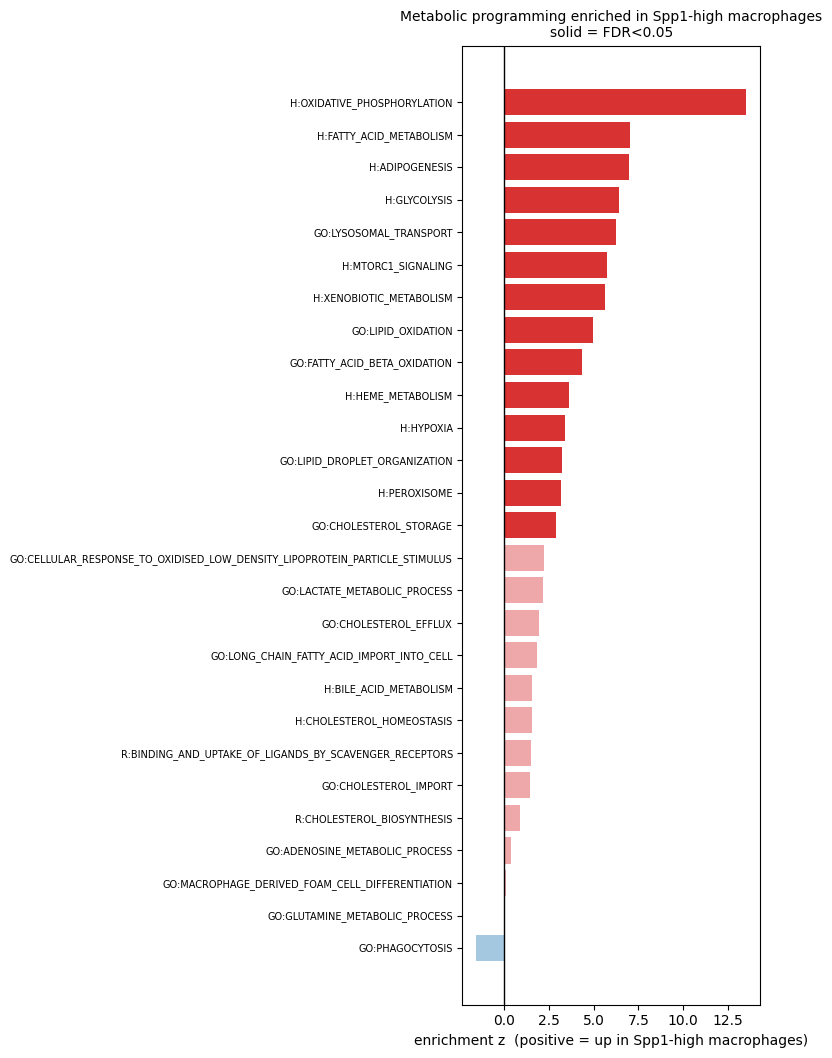


--- read ---
AUC / z > 0 = the pathway's genes concentrate at the Spp1-HIGH end of the DE.
The curated metabolic sets sitting ABOVE the non-metabolic HALLMARK backdrop (IFN, inflammatory,
etc.) is what makes 'this is a metabolic program' a quantitative claim, not an eyeball on the
gene list. Lipid / cholesterol / lysosomal-adjacent sets on top = the PDF's lipid-handling TAM.



In [ ]:
# %% -- 4c. Metabolic enrichment of the Spp1-hi vs -lo macrophage DE --
from scipy.stats import norm, hypergeom
from statsmodels.stats.multitest import multipletests

PATHWAY_DIR = Path("/coh_labs/yunroseli/Jona/CAR-T/data/references/pathways")
GMT_FILES = {
    "hallmark": PATHWAY_DIR / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": PATHWAY_DIR / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    PATHWAY_DIR / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  PATHWAY_DIR / "m2.cp.v2026.1.Mm.symbols.gmt",
}
def read_gmt(p):
    out = {}
    for line in open(p):
        x = line.rstrip("\n").split("\t")
        if len(x) >= 3: out[x[0]] = x[2:]
    return out
gene_sets = {}
for _, p in GMT_FILES.items():
    gene_sets.update(read_gmt(p))

# curated metabolic focus (verified present earlier); code skips any that are missing
METAB_FOCUS = [
    "GOBP_FATTY_ACID_BETA_OXIDATION", "GOBP_LIPID_DROPLET_ORGANIZATION",
    "GOBP_CELLULAR_RESPONSE_TO_OXIDISED_LOW_DENSITY_LIPOPROTEIN_PARTICLE_STIMULUS",
    "GOBP_LIPID_OXIDATION", "GOBP_CHOLESTEROL_EFFLUX", "GOBP_CHOLESTEROL_STORAGE",
    "GOBP_CHOLESTEROL_IMPORT", "REACTOME_CHOLESTEROL_BIOSYNTHESIS",
    "GOBP_LONG_CHAIN_FATTY_ACID_IMPORT_INTO_CELL", "GOBP_LACTATE_METABOLIC_PROCESS",
    "GOBP_ADENOSINE_METABOLIC_PROCESS", "GOBP_GLUTAMINE_METABOLIC_PROCESS",
    "GOBP_MACROPHAGE_DERIVED_FOAM_CELL_DIFFERENTIATION",
    "REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS",
    "GOBP_PHAGOCYTOSIS", "GOBP_LYSOSOMAL_TRANSPORT",
]
hallmark = {k: v for k, v in gene_sets.items() if k.startswith("HALLMARK_")}
panel = dict(hallmark)
for gs in METAB_FOCUS:
    if gs in gene_sets:
        panel[gs] = gene_sets[gs]
    else:
        print("missing from GMT:", gs)

# a set is "metabolic" if it is in the curated focus, or a metabolic HALLMARK
METAB_HALLMARK_KEYS = ["GLYCOLYSIS", "OXIDATIVE_PHOS", "FATTY_ACID", "CHOLESTEROL", "ADIPO",
                       "MTORC1", "HYPOXIA", "BILE_ACID", "HEME", "PEROXISOME", "XENOBIOTIC"]
metab_tag = set(METAB_FOCUS) | {h for h in hallmark if any(k in h for k in METAB_HALLMARK_KEYS)}

# rank every gene by signed DE score (scanpy's Wilcoxon z; + = up in Spp1-high)
ds = de_df.set_index("gene")["score"].dropna()
ranked = ds.sort_values()
N = len(ranked)
rankpos = pd.Series(np.arange(1, N + 1), index=ranked.index)   # high rank = up in Spp1-high
tested = set(ranked.index)
up_genes = set(de_df[(de_df["pval_adj"] < 0.05) & (de_df["log2FC"] > 1)]["gene"]) & tested
K = len(up_genes)
print(f"background genes: {N:,} | up-genes (padj<0.05 & log2FC>1): {K:,}")

rows = []
for name, members in panel.items():
    m = [g for g in set(members) if g in tested]
    n = len(m)
    if n < 5:
        continue
    U = rankpos.loc[m].sum() - n * (n + 1) / 2         # Mann-Whitney U, in-set vs rest
    mu = n * (N - n) / 2
    sd = np.sqrt(n * (N - n) * (N + 1) / 12)
    z = (U - mu) / sd
    auc = U / (n * (N - n))                            # >0.5 = up in Spp1-high
    k = len(set(m) & up_genes)
    p_ora = float(hypergeom.sf(k - 1, N, K, n)) if K else np.nan
    rows.append({"pathway": name.replace("HALLMARK_", "H:").replace("GOBP_", "GO:").replace("REACTOME_", "R:"),
                 "raw": name, "n_genes": n, "AUC": round(auc, 3), "z": z,
                 "p_rank": float(2 * norm.sf(abs(z))),
                 "n_up_overlap": k, "p_ora": p_ora, "metabolic": name in metab_tag})
enr = pd.DataFrame(rows)
enr["fdr_rank"] = multipletests(enr["p_rank"], method="fdr_bh")[1]
enr["fdr_ora"] = np.nan
ora_ok = enr["p_ora"].notna()
enr.loc[ora_ok, "fdr_ora"] = multipletests(enr.loc[ora_ok, "p_ora"], method="fdr_bh")[1]
enr = enr.sort_values("z", ascending=False)
enr.to_csv(OUT_DIR / "sc_de_mac_metabolic_enrichment.csv", index=False)

print("\n=== TOP enriched up in Spp1-high macs (all sets; metabolic flagged) ===")
print(enr.head(15)[["pathway", "n_genes", "AUC", "z", "fdr_rank", "n_up_overlap", "metabolic"]]
      .round(3).to_string(index=False))
print("\n=== METABOLIC sets only (the focus), ranked by enrichment ===")
met = enr[enr["metabolic"]].sort_values("z", ascending=False)
print(met[["pathway", "n_genes", "AUC", "z", "fdr_rank", "n_up_overlap", "fdr_ora"]]
      .round(3).to_string(index=False))

# figure: metabolic sets by signed enrichment z
plot = met.sort_values("z")
sig = (plot["fdr_rank"] < 0.05).values
import matplotlib.colors as mcolors
bar_cols = [mcolors.to_rgba("#d62728" if v > 0 else "#1f77b4", 0.95 if s else 0.4)
            for v, s in zip(plot["z"].values, sig)]
fig, ax = plt.subplots(figsize=(7.8, 0.34 * len(plot) + 1.5))
ax.barh(range(len(plot)), plot["z"].values, color=bar_cols)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot["pathway"], fontsize=7)
ax.set_xlabel("enrichment z  (positive = up in Spp1-high macrophages)")
ax.set_title("Metabolic programming enriched in Spp1-high macrophages\nsolid = FDR<0.05", fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_metabolic_enrichment.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

print(f"""
--- read ---
AUC / z > 0 = the pathway's genes concentrate at the Spp1-HIGH end of the DE.
The curated metabolic sets sitting ABOVE the non-metabolic HALLMARK backdrop (IFN, inflammatory,
etc.) is what makes 'this is a metabolic program' a quantitative claim, not an eyeball on the
gene list. Lipid / cholesterol / lysosomal-adjacent sets on top = the PDF's lipid-handling TAM.
""")

## 5. Signature selection — hardened against spillover

Naive "top N by Wilcoxon score" fails twice here, and the v1 output showed both:

1. **No detection gap.** `Ftl1` (0.97 vs 0.83), `Lyz2` (0.95 vs 0.86), `Ctsb` (0.93 vs 0.68)
   are near-ceiling in *both* groups — high score, almost no information.
2. **Wrong lineage.** `Pdpn` ranked 12th and is a **fibroblast** marker; fibroblasts were the
   highest-mean-Spp1 type in v1. A fibroblast gene inside a macrophage signature re-imports
   the contamination one level up — the same failure, rebuilt.

So: significance **+** detection gap **+** macrophage-specificity vs the neighbours that spill
onto them. `Spp1` stays excluded — it is the contaminated gene.

In [ ]:
NON_MAC = [c for c in sc_ct.unique() if c not in SC_MAC_LABELS]

ct_means = {}
for c in SC_MAC_LABELS + NON_MAC:
    m = sc_ct.values == c
    if m.sum() < 20:
        continue
    sub = scref[m].X
    ct_means[c] = np.asarray(sub.mean(axis=0)).ravel() if sp.issparse(sub) else np.asarray(sub.mean(axis=0)).ravel()
ct_means = pd.DataFrame(ct_means, index=scref.var_names)

mac_mu = ct_means[[c for c in SC_MAC_LABELS if c in ct_means.columns]].mean(axis=1)
other_cols = [c for c in ct_means.columns if c not in SC_MAC_LABELS]
other_mu = ct_means[other_cols].max(axis=1)
spec = (mac_mu + 1e-3) / (other_mu + 1e-3)

cand = de_df[(de_df["pval_adj"] < 0.05) & (de_df["log2FC"] > 0.5) & (de_df["gene"] != "Spp1")].copy()
cand["gap"] = cand["pct_high"] - cand["pct_low"]
cand["mac_specificity"] = cand["gene"].map(spec)
cand["max_other_ct"] = cand["gene"].map(ct_means[other_cols].idxmax(axis=1))

# --- RELAXED for SPATIAL localisation (single-cell already carries the metabolic rigor) ---
# The strict >2x filter removed the interpretable lipid/lysosomal core (Apoe, Fabp5, cathepsins,
# Abca1) for being shared with other cell types. For spatial we want breadth + interpretability,
# so relax specificity and keep them; blacklist only the demonstrated cross-lineage contaminant.
# RE-CHECK §6 delta/rho after running this: if delta stays high the spillover is tolerable; if it
# collapses, raise MAC_SPEC_MIN back toward 2.0.
MAC_SPEC_MIN = 0.5     # was 2.0. lower = broader/looser; raise to tighten.
GAP_MIN      = 0.20    # was 0.25. still must separate Spp1-high from -low macs.
BLACKLIST    = {"Spp1", "Pdpn"}   # Spp1 = spillover; Pdpn = fibroblast marker (spec 0.36)
keep = cand[(cand["gap"] > GAP_MIN) & (cand["mac_specificity"] > MAC_SPEC_MIN)
            & (~cand["gene"].isin(BLACKLIST))]
sig_genes = keep.nlargest(N_SIG_GENES, "gap")["gene"].tolist()
keep.to_csv(OUT_DIR / "sc_signature_selection.csv", index=False)
pd.Series(sig_genes, name="gene").to_csv(OUT_DIR / "sc_spp1_tam_signature.csv", index=False)

print("=== signature selection (RELAXED for spatial) ===")
print(f"  padj<0.05 & log2FC>0.5                    : {len(cand)}")
print(f"  + detection gap > {GAP_MIN}                     : {int((cand['gap'] > GAP_MIN).sum())}")
print(f"  + mac-spec > {MAC_SPEC_MIN} & not blacklisted -> KEPT : {len(keep)}")
print(f"\n=== SPP1-TAM signature: {len(sig_genes)} genes (Spp1 excluded) ===")
print(keep.nlargest(N_SIG_GENES, "gap")[
    ["gene", "log2FC", "gap", "pct_high", "pct_low", "mac_specificity", "max_other_ct"]
].round(3).to_string(index=False))

print("\n=== dropped despite a high score (this is the filter working) ===")
print(cand[~cand["gene"].isin(sig_genes)].nlargest(12, "score")[
    ["gene", "score", "gap", "pct_low", "mac_specificity", "max_other_ct"]].round(3).to_string(index=False))
assert len(sig_genes) >= 10, "Too few genes survived - loosen `gap` or `mac_specificity`"

## 6. Transfer to spatial + calibrate

The test: a multi-gene, lineage-filtered signature should separate macrophages from B cells in
spatial **where raw Spp1 could not** (there, B cells *beat* macrophages).

In [ ]:
import spatialdata as spd
ZARR_FILE = Path("/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC")
sdata = spd.read_zarr(ZARR_FILE)
adata = sdata.tables["segmentation_counts"]

SP_CT_COL = "c2l_consolidated"
MAC_LABELS = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
sp_ct = adata.obs[SP_CT_COL].astype(str)
adata.obs["is_mac"] = sp_ct.isin(MAC_LABELS).values
is_b = (sp_ct == "B").values

present = [g for g in sig_genes if g in adata.var_names]
print(f"signature genes present in spatial: {len(present)}/{len(sig_genes)}")
if len(present) < len(sig_genes):
    print(f"missing: {[g for g in sig_genes if g not in adata.var_names]}")
assert len(present) >= 10, "Too few signature genes in the spatial object to score reliably"

sc.tl.score_genes(adata, gene_list=present, score_name="SPP1_TAM_sig", use_raw=False, random_state=0)

mac_m = adata.obs["is_mac"].values
sig_mac = adata.obs.loc[mac_m, "SPP1_TAM_sig"].values
sig_b = adata.obs.loc[is_b, "SPP1_TAM_sig"].values
u = mannwhitneyu(sig_mac, sig_b, alternative="two-sided")
delta = 2 * u.statistic / (len(sig_mac) * len(sig_b)) - 1

_s = adata.layers["counts"][:, int(adata.var_names.get_loc("Spp1"))]
spp1_raw_all = np.asarray(_s.todense()).ravel() if sp.issparse(_s) else np.asarray(_s).ravel()
rho = float(pd.Series(spp1_raw_all[mac_m]).corr(pd.Series(sig_mac), method="spearman"))

print(f"""
=== SC signature scored on SPATIAL ===
  mean in macrophages : {sig_mac.mean():+.4f}
  mean in B cells     : {sig_b.mean():+.4f}
  Cliff's delta       : {delta:+.3f}    (mac vs B; want STRONGLY POSITIVE)
  Spearman vs raw Spp1: {rho:+.3f}     (within macs; want LOW/MODERATE)

  delta strongly + and rho low -> the signature is macrophage-specific in spatial where the
      single gene was not, AND carries information the contaminated gene does not. Use it.
  rho very high -> the signature is a proxy for raw Spp1 and inherits its contamination;
      fall back to the local-background correction (01b definition D).
""")

In [ ]:
# %% -- 6b. The 210,019 SPATIAL "Erythrocytes": real, or mislabelled tumour? --
# The one that actually matters: ~10% of cells, in NUCLEI-segmented (StarDist) data, for a cell
# type that has no nucleus. If they are tumour, the §3 tumour gate strengthens (tumour count
# rises from 363,019 toward ~573,000) and ~10% of the spatial annotation needs revisiting.
ery_sp = (sp_ct == "Erythrocyte").values
tum_sp = (sp_ct == "Cancer_cell").values
CHK = ["Hba-a1", "Hba-a2", "Hbb-bs", "Alas2", "Epcam", "Krt8", "Krt18", "Spp1", "Mki67"]
print(f"spatial Erythrocyte: {int(ery_sp.sum()):,} cells ({100*ery_sp.mean():.1f}% of all) | "
      f"Cancer_cell: {int(tum_sp.sum()):,}")
print(f"\n{'gene':10s}{'eryth_mean':>12s}{'tumour_mean':>12s}  (raw UMI)")
for g in CHK:
    if g in adata.var_names:
        v = adata.layers["counts"][:, int(adata.var_names.get_loc(g))]
        v = np.asarray(v.todense()).ravel() if sp.issparse(v) else np.asarray(v).ravel()
        print(f"{g:10s}{v[ery_sp].mean():12.3f}{v[tum_sp].mean():12.3f}")
print("""
READ
  Hb-high + Epcam ~0  -> genuine red-blood-cell / blood contamination (expected; just exclude
                         'Erythrocyte' from the analyses - which the pipeline already does).
  Epcam/Krt-high      -> mislabelled tumour. StarDist segments NUCLEI, so these DO have nuclei and
                         are not RBCs -> the tumour Spp1 gate is an under-estimate and a tenth of
                         the spatial annotation needs a second look (beyond this Spp1 question).""")

In [ ]:
sc_frac = float((mac.obs["spp1_grp"] == "Spp1_high").mean())
cut = np.quantile(sig_mac, 1 - sc_frac)
adata.obs["spp1_tam"] = False
adata.obs.loc[mac_m, "spp1_tam"] = sig_mac >= cut
n_sel = int(adata.obs["spp1_tam"].sum())
b_rate = 100 * float((sig_b >= cut).mean())

print(f"""=== calibrated spatial definition ===
  SC Spp1-high fraction of macs : {100*sc_frac:.1f}%   (the target)
  signature cut                 : {cut:.4f}
  spatial macs selected         : {n_sel:,} ({100*n_sel/mac_m.sum():.1f}% of macs)
  B cells passing the same cut  : {b_rate:.1f}%   <- was 89.5% on raw Spp1>=2

per-tissue counts of spp1_tam (drives 02/03 power):
{adata.obs[adata.obs['spp1_tam']].groupby(adata.obs['tissue'].astype(str)).size().describe().round(1).to_string()}
""")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].hist(sig_mac, bins=80, color="#d62728", alpha=0.75, label="macrophages", density=True)
axes[0].hist(sig_b, bins=80, color="#7f7f7f", alpha=0.55, label="B cells", density=True)
axes[0].axvline(cut, color="k", ls="--", lw=1.2, label=f"cut (top {100*sc_frac:.0f}%)")
axes[0].set_title("SPP1-TAM signature in spatial\n(raw Spp1 could not separate these)", fontsize=9)
axes[0].set_xlabel("signature score"); axes[0].legend(fontsize=8, frameon=False)

rng = np.random.default_rng(0)
sub = rng.choice(np.where(mac_m)[0], size=min(20000, int(mac_m.sum())), replace=False)
axes[1].scatter(np.log1p(spp1_raw_all[sub]), adata.obs["SPP1_TAM_sig"].values[sub],
                s=2, alpha=0.06, color="#1f77b4", linewidths=0)
axes[1].axhline(cut, color="k", ls="--", lw=1.2)
axes[1].set_xlabel("log1p(raw Spp1 UMI)"); axes[1].set_ylabel("SPP1_TAM signature")
axes[1].set_title(f"signature vs raw Spp1 in macs\nSpearman rho = {rho:.3f}", fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_signature_in_spatial.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

adata.obs[["tissue", SP_CT_COL, "is_mac", "SPP1_TAM_sig", "spp1_tam"]].to_parquet(
    OUT_DIR / "spp1_tam_signature_labels.parquet")

print(f"""
==================== SUMMARY — report these back ====================
Reference used   : {SC_REF}
Annotation level : {SC_CELLTYPE_COL}  ({best_ov}/{len(SPATIAL_LABELS)} spatial labels matched)
Macrophages      : {mac.n_obs:,}  ({'+'.join(SC_MAC_LABELS)})

1. §2 level auto-detection + vocabulary  -> did lvl2 win, and do the labels line up?
2. §3 Spp1-by-celltype + THE TUMOUR GATE -> does Cancer_cell or macrophage dominate Spp1?
3. §4 top-30 DE + marker-program check   -> does the lipid/TREM2 program hold on the correct
                                            annotation? (it did on the coarse one)
4. §5 signature + the 'dropped' table    -> is the filter removing Pdpn/Ftl1/Lyz2/Ctsb?
5. §6 Cliff's delta, rho, B-cell rate    -> THE test.

If §6 passes I will rewrite 02-04 around `SPP1_TAM_sig` as a GRADED score: "among
macrophages, does the SPP1-TAM program rise with the local niche score?" instead of "is the
Spp1+ mac inside the hotspot?". Threshold-free, uses every macrophage, effect size is a
regression slope.
=====================================================================
""")